<a href="https://colab.research.google.com/github/Sumant-crty/Insight/blob/main/MainwarehousevehicleANPR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
opencv-python
easyocr

Processing image... please wait.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



--- ALL DETECTION RESULTS ---
Detected Text: IND
Confidence Score: 1.00
Detected Text: 22BH 65I7 A
Confidence Score: 0.74


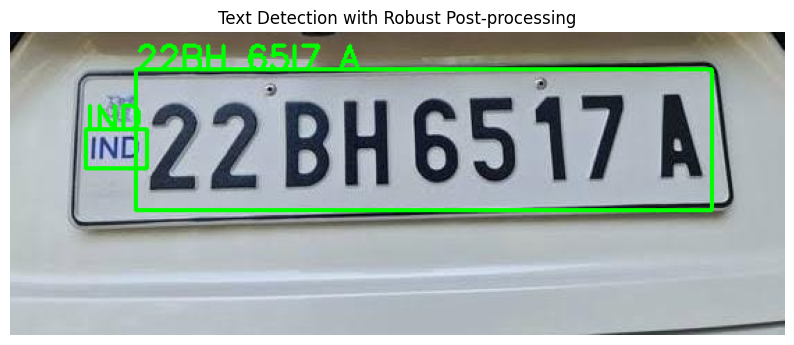

In [19]:
import cv2
import easyocr
import matplotlib.pyplot as plt

# Function to perform robust post-processing on detected text
def clean_license_plate_text(text):
    # Convert to uppercase and remove all spaces for initial cleaning
    cleaned_text = text.replace(' ', '').upper()

    # Common OCR error corrections for license plates
    # '4' is often misread as 'A', '8' as 'B', '0' as 'O', '1' as 'I', etc.
    # Apply specific corrections relevant to common confusions
    cleaned_text = cleaned_text.replace('4', 'A')
    cleaned_text = cleaned_text.replace('8', 'B')
    cleaned_text = cleaned_text.replace('0', 'O') # Example, adjust as needed
    cleaned_text = cleaned_text.replace('1', 'I') # Example, adjust as needed

    # Attempt to format based on expected license plate structure (e.g., Indian plates)
    # This is an example; a more complex regex could be used for varying patterns
    if len(cleaned_text) == 9 and cleaned_text.startswith('22BH') and cleaned_text.endswith('A'):
        # Reconstruct as '22BH 6517 A' format
        return cleaned_text[:4] + ' ' + cleaned_text[4:8] + ' ' + cleaned_text[8]
    elif len(cleaned_text) == 9:
        # General formatting for 9-char plates if the above doesn't match exactly
        return cleaned_text[:2] + ' ' + cleaned_text[2:4] + ' ' + cleaned_text[4:8] + ' ' + cleaned_text[8]

    # If no specific pattern matches, return the cleaned text
    return cleaned_text

# 1. Initialize the Reader (English language)
# 'gpu=False' if you don't have an NVIDIA graphics card
reader = easyocr.Reader(['en'], gpu=False)

# 2. Load your image
image_path = 'test_image1.jpg'
image = cv2.imread(image_path)

# Check if image was loaded successfully
if image is None:
    print(f"Error: Could not load image from {image_path}.")
    print("Please ensure the image file exists and the path is correct.")
else:
    # 3. Apply basic Preprocessing (grayscale) for better OCR accuracy
    # Convert to grayscale
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # 4. Perform OCR on the preprocessed (grayscale) image
    print("Processing image... please wait.")
    results = reader.readtext(gray_image) # Use gray_image directly

    # 5. Display Results with robust post-processing
    print("\n--- ALL DETECTION RESULTS ---")
    if not results:
        print("No text detected.")

    all_processed_texts = []
    for (bbox, text, prob) in results:
        processed_text = clean_license_plate_text(text)
        all_processed_texts.append((bbox, processed_text, prob, text)) # Store original text for display
        print(f"Detected Text: {processed_text}")
        print(f"Confidence Score: {prob:.2f}")

    # Optional: Draw a box around all detected text and show it
    display_image = image.copy() # Make a copy to draw on the original image for clarity
    for (bbox, processed_text, prob, original_text) in all_processed_texts:
        (tl, tr, br, bl) = bbox
        cv2.rectangle(display_image, tuple(map(int, tl)), tuple(map(int, br)), (0, 255, 0), 2)
        # Use the post-processed text for display on the image
        cv2.putText(display_image, processed_text, tuple(map(int, tl)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

    # Display the image using matplotlib for Colab compatibility
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(display_image, cv2.COLOR_BGR2RGB)) # Convert BGR to RGB for matplotlib
    plt.title("Text Detection with Robust Post-processing")
    plt.axis('off')
    plt.show()

In [17]:
pip install --upgrade easyocr